# RandLA-Net — Airbus Hackathon 2026
## Segmentation LiDAR 3D + Détection d'Obstacles

Ce notebook orchestre tout le pipeline :
1. Setup environnement
2. Récupération des données depuis GCS
3. Preprocessing
4. Entraînement
5. Inférence + génération CSV
6. Visualisation

**Machine recommandée:** g2-standard-16 + NVIDIA L4 (24Go VRAM)

## 1. Setup Environnement

In [16]:
# Vérifier le GPU
!nvidia-smi
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    # Dans une cellule Jupyter
!gcloud storage cp -r gs://bucketj2b/airbus_hackathon_evalset .

Sun Mar  8 03:26:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.90.07              Driver Version: 550.90.07      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      On  |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P8             17W /   72W |       4MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Installer les dépendances manquantes
!pip install -q h5py open3d scipy scikit-learn tqdm

In [3]:
import os

# Pull les dernières modifications du repo
!git pull
print(f"Working dir: {os.getcwd()}")

hint: Pulling without specifying how to reconcile divergent branches is
hint: discouraged. You can squelch this message by running one of the following
hint: commands sometime before your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
Already up to date.
Working dir: /home/jupyter/HackatonAHv2


## 2. Récupérer les données depuis Google Cloud Storage

In [4]:
# Copier les données depuis le bucket GCS
BUCKET = "gs://j2b-hackaton-airbus-2026"  # ← ADAPTER si différent
DATA_DIR = "airbus_hackathon_trainingdata"

if not os.path.exists(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    os.makedirs(DATA_DIR, exist_ok=True)
    !gsutil -m cp -r {BUCKET}/{DATA_DIR}/* {DATA_DIR}/
    print(f"Données copiées: {len(os.listdir(DATA_DIR))} fichiers")
else:
    print(f"Données déjà présentes: {len(os.listdir(DATA_DIR))} fichiers")

# Vérifier
!ls -lh {DATA_DIR}/

Données déjà présentes: 10 fichiers
total 1.6G
-rw-r--r-- 1 jupyter jupyter 156M Mar  7 00:52 scene_1.h5
-rw-r--r-- 1 jupyter jupyter 161M Mar  7 00:52 scene_10.h5
-rw-r--r-- 1 jupyter jupyter 168M Mar  7 00:52 scene_2.h5
-rw-r--r-- 1 jupyter jupyter 155M Mar  7 00:52 scene_3.h5
-rw-r--r-- 1 jupyter jupyter 159M Mar  7 00:52 scene_4.h5
-rw-r--r-- 1 jupyter jupyter 171M Mar  7 00:52 scene_5.h5
-rw-r--r-- 1 jupyter jupyter 158M Mar  7 00:52 scene_6.h5
-rw-r--r-- 1 jupyter jupyter 164M Mar  7 00:52 scene_7.h5
-rw-r--r-- 1 jupyter jupyter 156M Mar  7 00:52 scene_8.h5
-rw-r--r-- 1 jupyter jupyter 162M Mar  7 00:52 scene_9.h5


## 3. Preprocessing

Convertit les fichiers HDF5 bruts en frames `.npz` individuelles.
- Filtre les tirs invalides
- Convertit sphérique → cartésien
- Assigne les class IDs depuis RGB
- Calcule les class weights

In [5]:
import time
import os

# Skip le preprocessing si déjà fait
stats_file = "processed_data/dataset_stats.json"
if os.path.exists(stats_file):
    print("Preprocessing déjà fait, skip. (supprimez processed_data/ pour relancer)")
else:
    t0 = time.time()
    !python prep_data.py
    print(f"\nPreprocessing terminé en {time.time()-t0:.0f}s")

Preprocessing déjà fait, skip. (supprimez processed_data/ pour relancer)


Frames totales: 997
Points totaux: 176,991,145

Class weights: ['4.39', '20.00', '13.53', '1.82', '0.03']


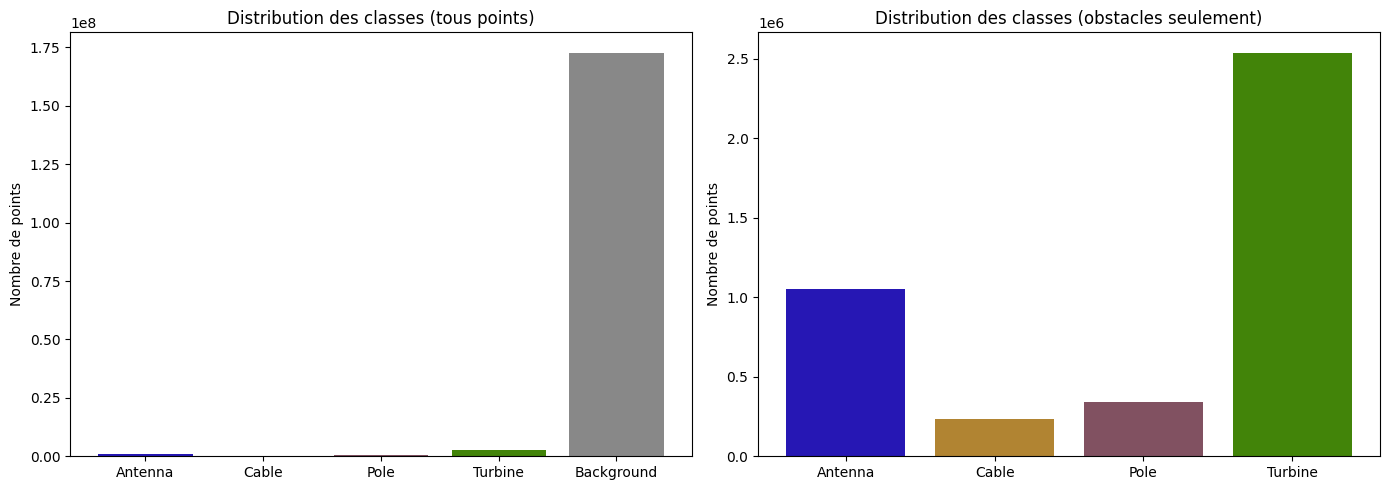

In [6]:
# Vérifier les stats
import json

with open("processed_data/dataset_stats.json") as f:
    stats = json.load(f)

print(f"Frames totales: {stats['total_frames']}")
print(f"Points totaux: {stats['total_points']:,}")
print(f"\nClass weights: {[f'{w:.2f}' for w in stats['class_weights']]}")

# Distribution des classes
import matplotlib.pyplot as plt
import numpy as np

names = ['Antenna', 'Cable', 'Pole', 'Turbine', 'Background']
counts = [stats['class_counts'].get(str(i), 0) for i in range(5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Toutes les classes
ax1.bar(names, counts, color=['#2617B4', '#B18432', '#815161', '#428409', '#888888'])
ax1.set_title('Distribution des classes (tous points)')
ax1.set_ylabel('Nombre de points')
ax1.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

# Sans background pour voir les proportions
ax2.bar(names[:4], counts[:4], color=['#2617B4', '#B18432', '#815161', '#428409'])
ax2.set_title('Distribution des classes (obstacles seulement)')
ax2.set_ylabel('Nombre de points')

plt.tight_layout()
plt.savefig('images/class_distribution.png', dpi=150)
plt.show()

## 4. Entraînement

RandLA-Net avec:
- Focal Loss + Lovász-Softmax
- Density augmentation (25-100%)
- Cosine annealing + warmup
- Mixed precision (AMP)

In [7]:
# Optionnel: ajuster la config avant training
from config import Config

# Vérifier les paramètres clés
cfg = Config()
print(f"Batch size: {cfg.batch_size}")
print(f"Epochs: {cfg.epochs}")
print(f"Learning rate: {cfg.lr}")
print(f"Num points: {cfg.num_points}")
print(f"Density drop: [{cfg.density_drop_min}, {cfg.density_drop_max}]")
print(f"AMP: {cfg.use_amp}")
print(f"Features dim: {cfg.d_in}")

Batch size: 14
Epochs: 300
Learning rate: 0.005
Num points: 65536
Density drop: [0.25, 1.0]
AMP: True
Features dim: 8


In [8]:
# LANCER L'ENTRAINEMENT
#t0 = time.time()
#!python train.py
#print(f"\nEntraînement terminé en {(time.time()-t0)/60:.1f} minutes")

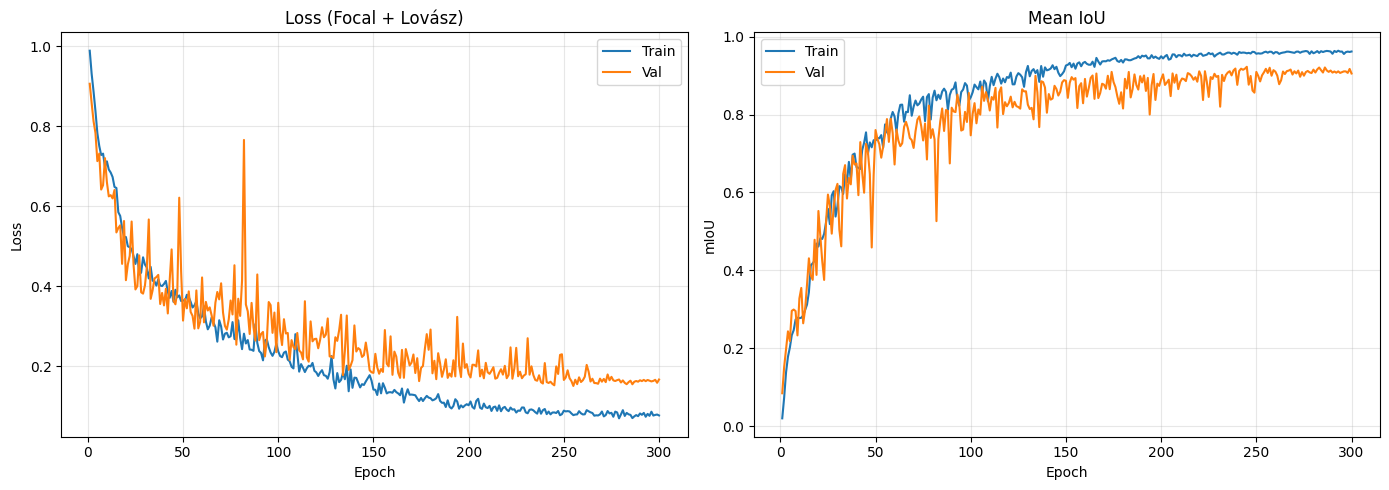


Meilleur epoch: 245
Val mIoU: 0.9226
  Antenna     : 0.8657
  Cable       : 0.8772
  Pole        : 0.9130
  Turbine     : 0.9581
  Background  : 0.9989


In [9]:
# Visualiser l'historique d'entraînement
with open('logs/training_history.json') as f:
    history = json.load(f)

epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]
train_miou = [h['train_miou'] for h in history]
val_miou = [h['val_miou'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, label='Train')
ax1.plot(epochs, val_loss, label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss (Focal + Lovász)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_miou, label='Train')
ax2.plot(epochs, val_miou, label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title('Mean IoU')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/training_curves.png', dpi=150)
plt.show()

# Best epoch
best = max(history, key=lambda h: h['val_miou'])
print(f"\nMeilleur epoch: {best['epoch']}")
print(f"Val mIoU: {best['val_miou']:.4f}")
class_names = ['Antenna', 'Cable', 'Pole', 'Turbine', 'Background']
for i, name in enumerate(class_names):
    iou = best['val_ious'][i]
    print(f"  {name:12s}: {iou:.4f}" if not np.isnan(iou) else f"  {name:12s}: N/A")

## 5. Inférence sur les données d'évaluation

Génère les 8 fichiers CSV requis (2 scènes × 4 densités)

In [10]:
# ═══ ADAPTER ces chemins quand les fichiers d'évaluation arrivent ═══
EVAL_DIR = "eval_data"  # Dossier contenant les .h5 d'évaluation
OUTPUT_DIR = "predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lister les fichiers d'évaluation
eval_files = sorted([f for f in os.listdir(EVAL_DIR) if f.endswith('.h5')]) if os.path.exists(EVAL_DIR) else []
print(f"Fichiers d'évaluation: {eval_files}")

Fichiers d'évaluation: []


In [11]:
# Lancer l'inférence sur chaque fichier
for eval_file in eval_files:
    input_path = os.path.join(EVAL_DIR, eval_file)
    output_name = eval_file.replace('.h5', '_predictions.csv')
    output_path = os.path.join(OUTPUT_DIR, output_name)
    
    print(f"\n{'='*60}")
    !python inference.py --input {input_path} --output {output_path}

print(f"\n\nTous les CSV générés dans {OUTPUT_DIR}/")
!ls -lh {OUTPUT_DIR}/



Tous les CSV générés dans predictions/
total 492K
-rw-r--r-- 1 jupyter jupyter 103K Mar  7 16:44 pred_scene1_100_v3.csv
-rw-r--r-- 1 jupyter jupyter  89K Mar  7 16:57 pred_scene1_25_legacy.csv
-rw-r--r-- 1 jupyter jupyter  92K Mar  7 16:25 pred_scene1_25_v3.csv
-rw-r--r-- 1 jupyter jupyter 103K Mar  7 16:31 pred_scene1_50_v3.csv
-rw-r--r-- 1 jupyter jupyter 100K Mar  7 16:37 pred_scene1_75_v3.csv


## 5b. Test sur les données d'entraînement (validation)

Pour vérifier que le modèle fonctionne avant l'évaluation.

In [12]:
# Tester sur une scène d'entraînement pour vérification
TEST_SCENE = "airbus_hackathon_trainingdata/scene_1.h5"
TEST_OUTPUT = "predictions/test_scene1.csv"

!python inference.py --input {TEST_SCENE} --output {TEST_OUTPUT}

# Afficher les résultats
import pandas as pd
df_pred = pd.read_csv(TEST_OUTPUT)
print(f"\nDétections totales: {len(df_pred)}")
print(f"\nPar classe:")
print(df_pred['class_label'].value_counts())

Device: cuda
Clustering: probabilistic-v3
Modèle chargé: checkpoints/best_model.pth
  Epoch: 279, Val mIoU: 0.8875725298359186

Traitement: airbus_hackathon_trainingdata/scene_1.h5
  Points totaux: 57,500,000
  Points valides: 24,912,785
  Frames: 100
  Voxel downsample: 299,435 → 189,419 points
  Frame   0: 1 détections
  Frame   1: 1 détections
  Frame   2: 2 détections
  Frame   3: 2 détections
  Frame   4: 1 détections
  Frame   5: 7 détections
  Frame   6: 8 détections
  Frame   7: 7 détections
  Frame   8: 7 détections
  Frame   9: 7 détections
  Frame  10: 1 détections
  Frame  11: 3 détections
  Frame  12: 11 détections
  Frame  13: 6 détections
  Frame  14: 19 détections
  Frame  15: 20 détections
  Frame  16: 1 détections
  Frame  17: 1 détections
  Frame  18: 1 détections
  Frame  19: 1 détections
  Frame  20: 5 détections
  Frame  21: 1 détections
  Frame  22: 1 détections
  Frame  23: 2 détections
  Frame  24: 1 détections
  Frame  25: 1 détections
  Frame  26: 1 détection

## 6. Visualisation

Générer les screenshots demandés (max 10 frames avec bounding boxes)

Sauvegardé: images/predictions/frame_1.png


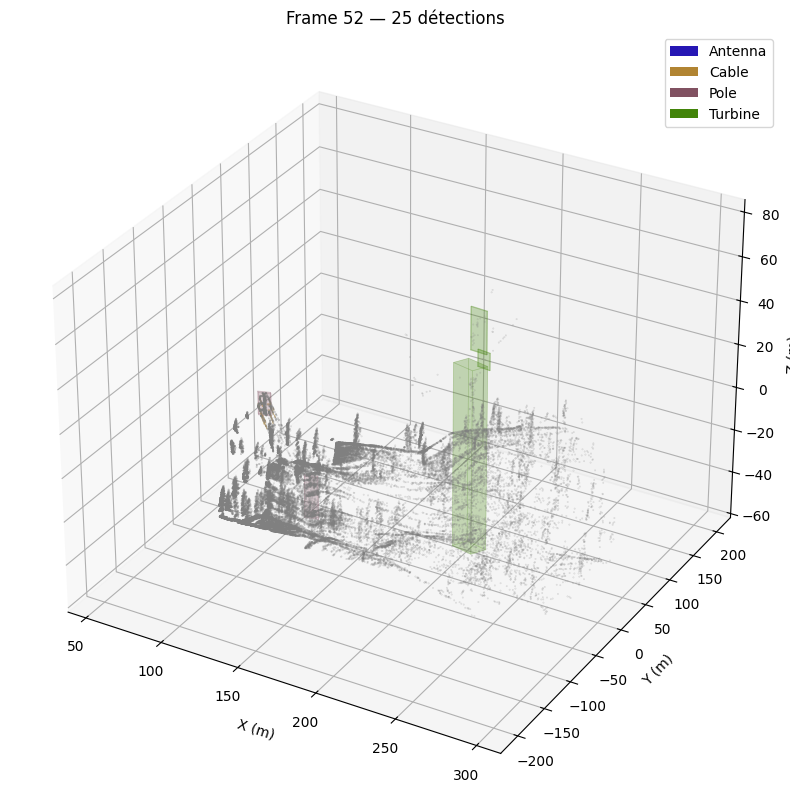

Sauvegardé: images/predictions/frame_2.png


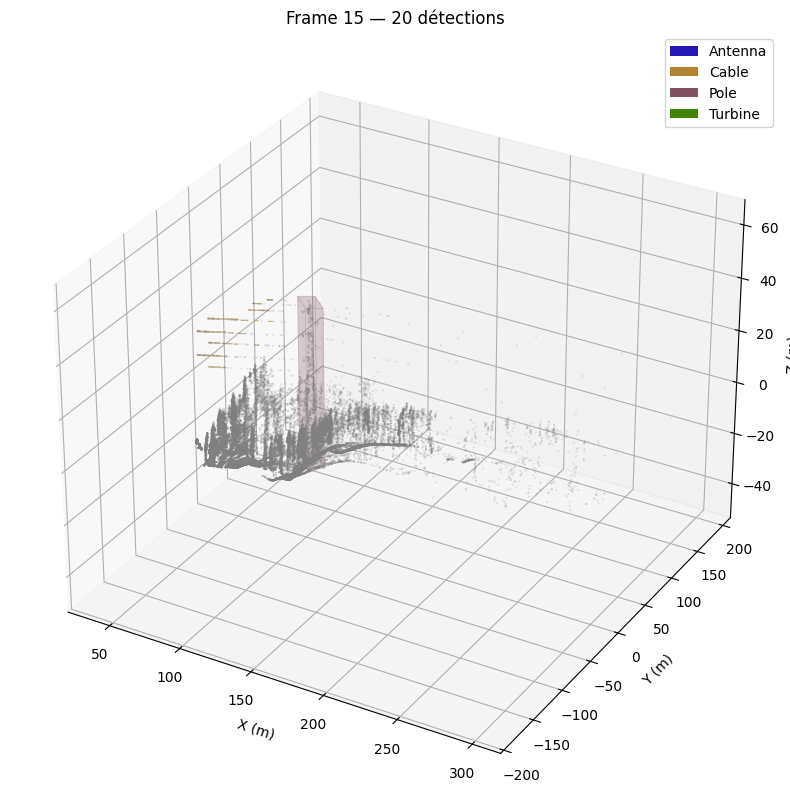

Sauvegardé: images/predictions/frame_3.png


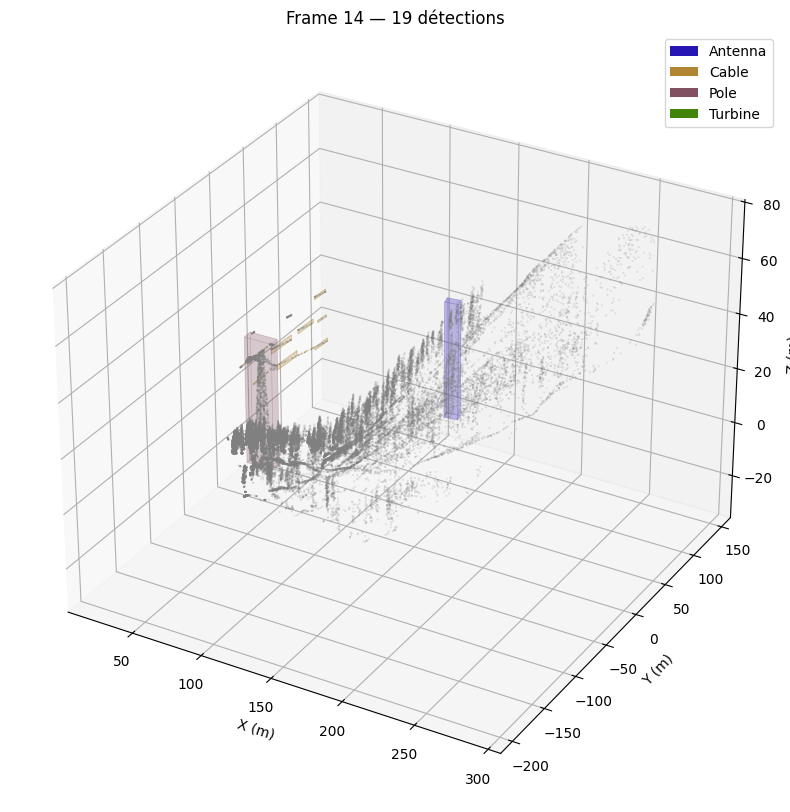

Sauvegardé: images/predictions/frame_4.png


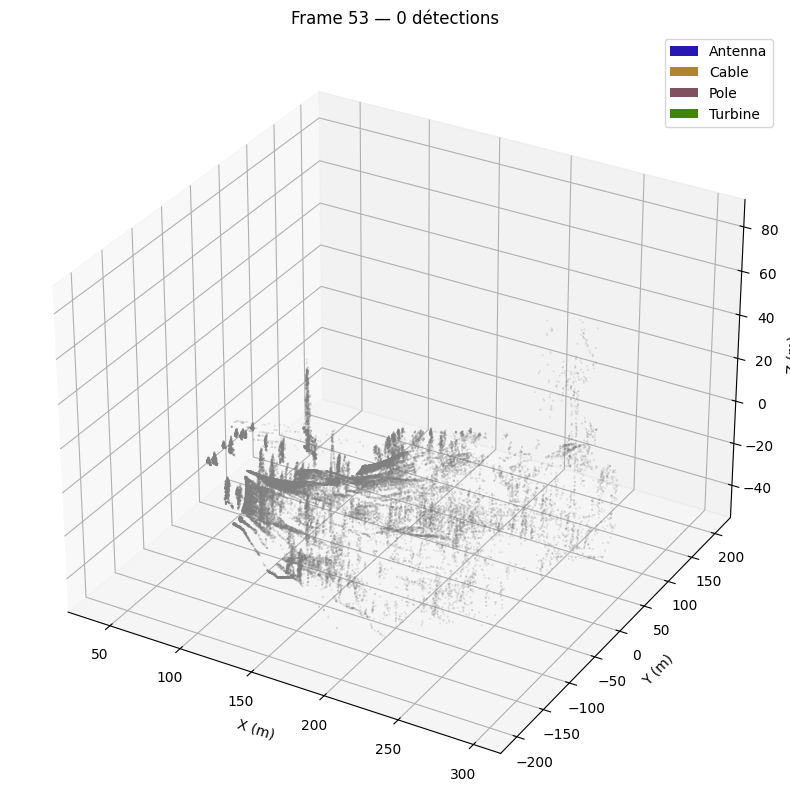

Sauvegardé: images/predictions/frame_5.png


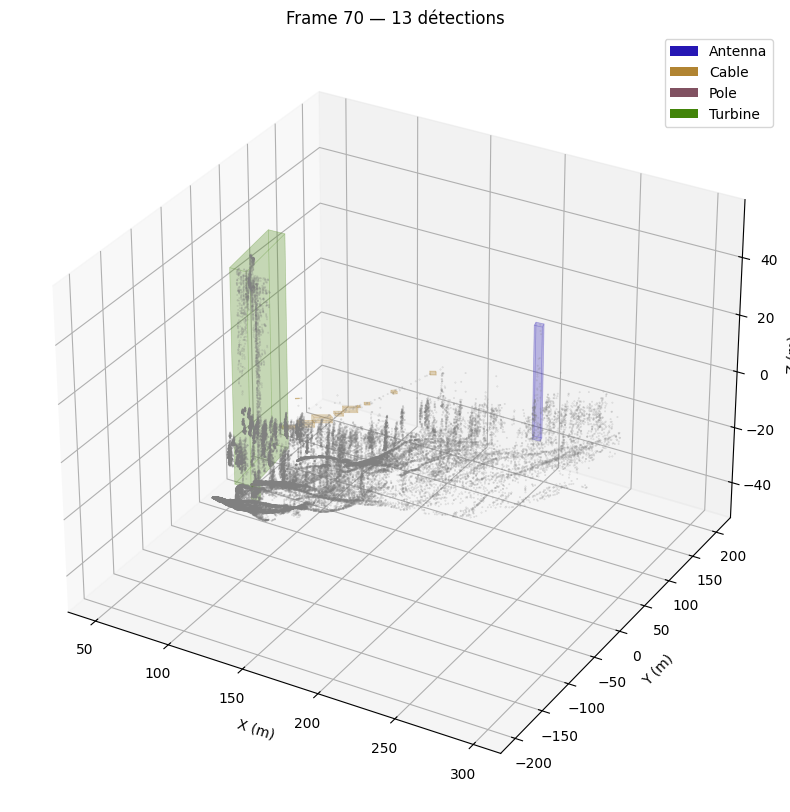

Sauvegardé: images/predictions/frame_6.png


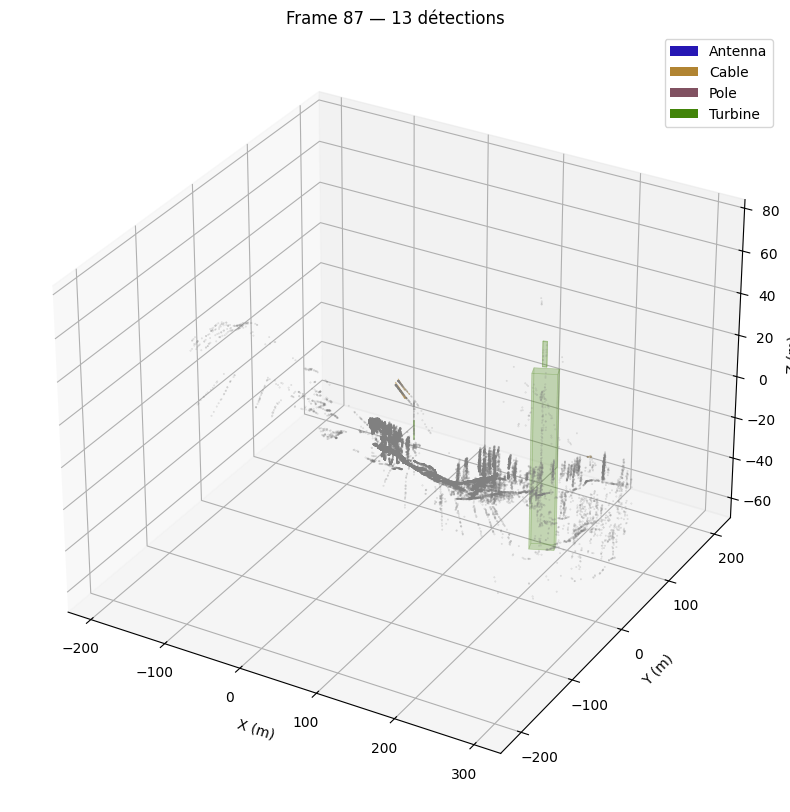

Sauvegardé: images/predictions/frame_7.png


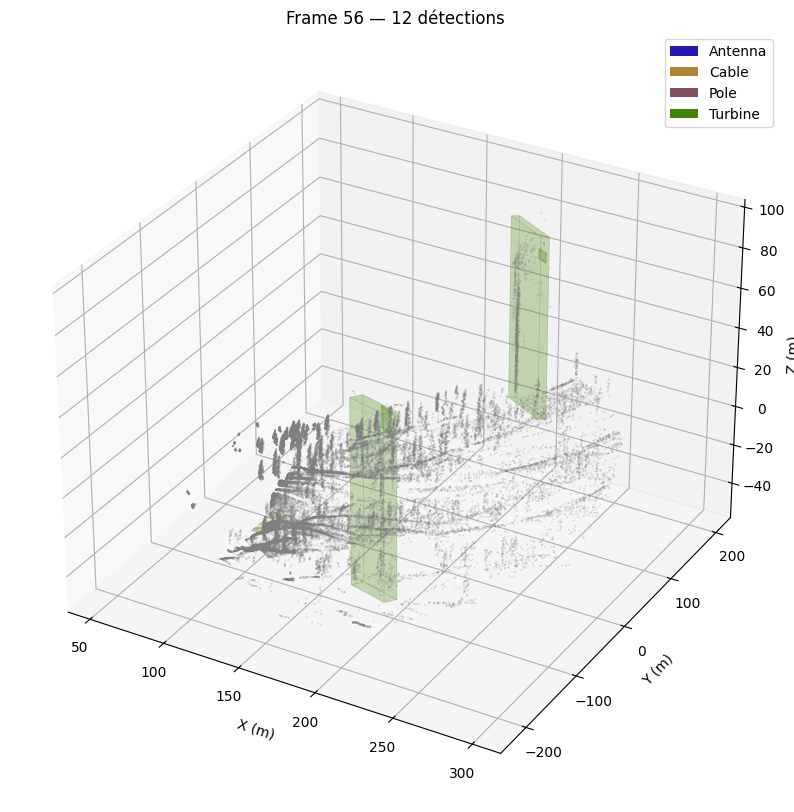

Sauvegardé: images/predictions/frame_8.png


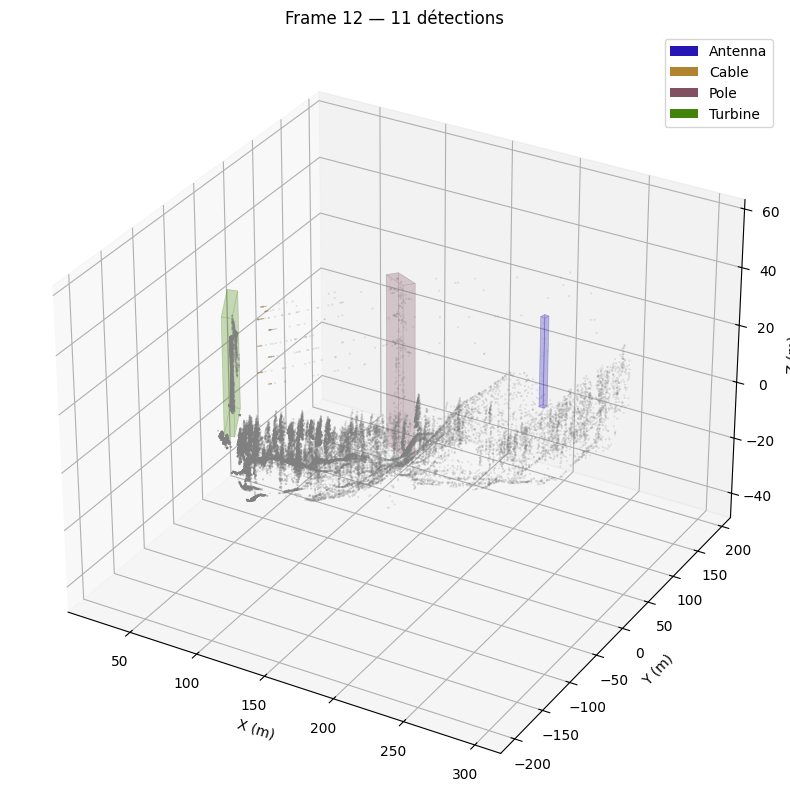

Sauvegardé: images/predictions/frame_9.png


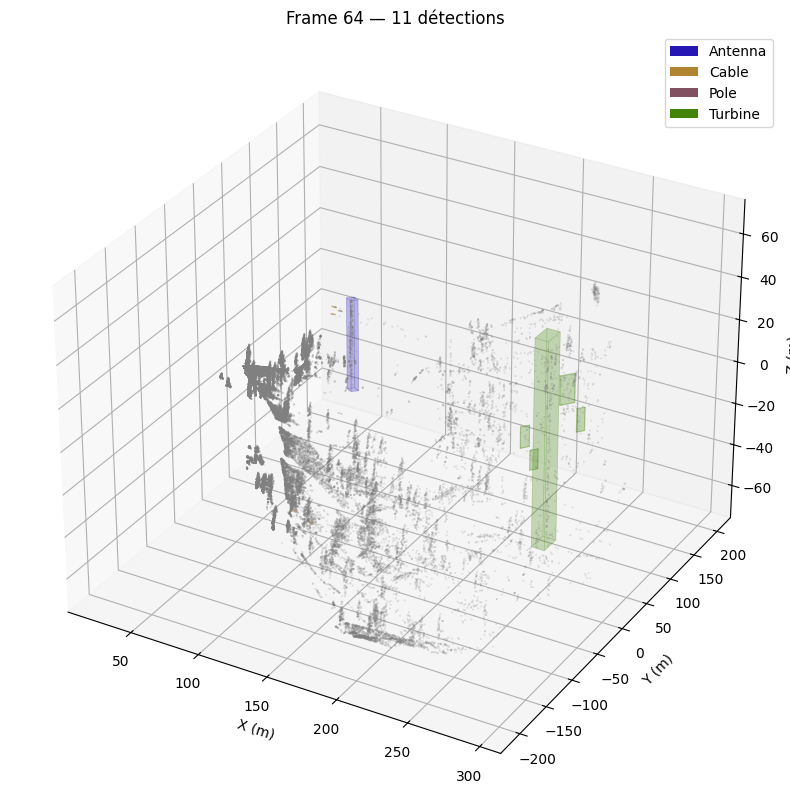

Sauvegardé: images/predictions/frame_10.png


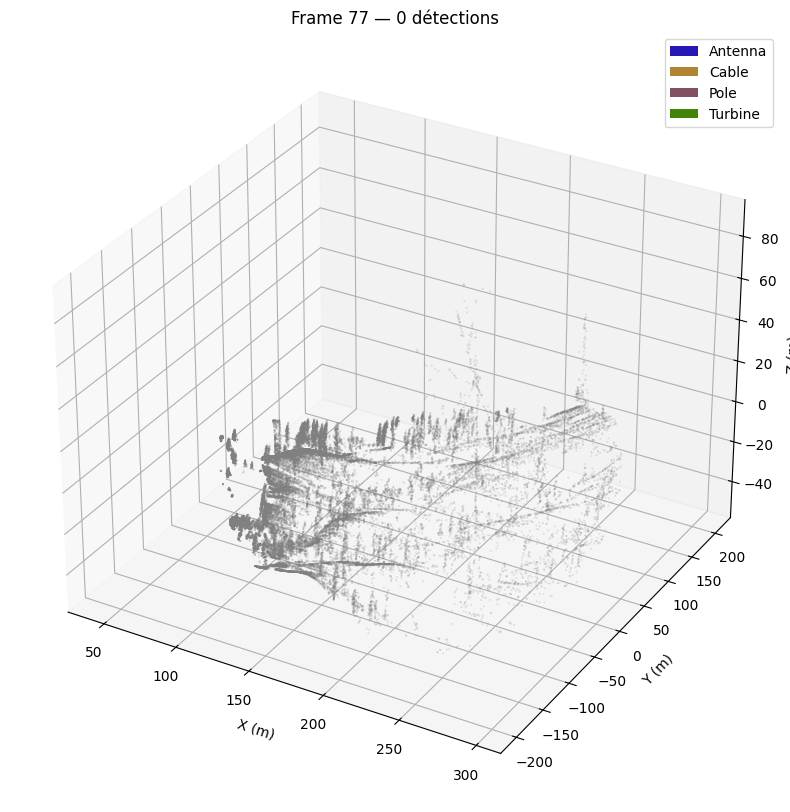

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import lidar_utils

CLASS_COLORS = {
    0: '#2617B4',  # Antenna - bleu
    1: '#B18432',  # Cable - or
    2: '#815161',  # Pole - rouge-brun
    3: '#428409',  # Turbine - vert
}

def draw_bbox_3d(ax, center, w, l, h, yaw, color, label):
    """Dessine une bounding box 3D orientée."""
    cx, cy, cz = center
    c, s = np.cos(yaw), np.sin(yaw)
    
    # 8 sommets de la boîte (avant rotation)
    dx, dy, dz = w/2, l/2, h/2
    corners = np.array([
        [-dx, -dy, -dz], [dx, -dy, -dz], [dx, dy, -dz], [-dx, dy, -dz],
        [-dx, -dy, dz], [dx, -dy, dz], [dx, dy, dz], [-dx, dy, dz]
    ])
    
    # Rotation autour de Z
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    corners = corners @ R.T + np.array([cx, cy, cz])
    
    # Dessiner les 6 faces
    faces = [
        [corners[i] for i in [0,1,2,3]], [corners[i] for i in [4,5,6,7]],
        [corners[i] for i in [0,1,5,4]], [corners[i] for i in [2,3,7,6]],
        [corners[i] for i in [0,3,7,4]], [corners[i] for i in [1,2,6,5]]
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.15, facecolor=color, edgecolor=color, linewidths=0.5))


def visualize_frame_with_boxes(scene_file, pose_index, predictions_df, save_path=None):
    """Visualise un frame avec les bounding boxes prédites."""
    df = lidar_utils.load_h5_data(scene_file)
    df = df[df['distance_cm'] > 0]
    poses = lidar_utils.get_unique_poses(df)
    
    if pose_index >= len(poses):
        print(f"Pose index {pose_index} hors limites")
        return
    
    pose = poses.iloc[pose_index]
    frame = lidar_utils.filter_by_pose(df, pose)
    xyz = lidar_utils.spherical_to_local_cartesian(frame)
    
    # Filtrer les predictions pour ce frame
    frame_preds = predictions_df[
        (predictions_df['ego_x'] == pose['ego_x']) &
        (predictions_df['ego_y'] == pose['ego_y']) &
        (predictions_df['ego_z'] == pose['ego_z']) &
        (predictions_df['ego_yaw'] == pose['ego_yaw'])
    ]
    
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Sous-échantillonner pour la visu (sinon trop lent)
    n_vis = min(50000, len(xyz))
    idx = np.random.choice(len(xyz), n_vis, replace=False)
    ax.scatter(xyz[idx, 0], xyz[idx, 1], xyz[idx, 2], s=0.1, c='gray', alpha=0.3)
    
    # Dessiner les bounding boxes
    for _, det in frame_preds.iterrows():
        cid = int(det['class_ID'])
        color = CLASS_COLORS.get(cid, 'red')
        center = [det['bbox_center_x'], det['bbox_center_y'], det['bbox_center_z']]
        draw_bbox_3d(ax, center, det['bbox_width'], det['bbox_length'],
                     det['bbox_height'], det['bbox_yaw'], color, det['class_label'])
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(f'Frame {pose_index} — {len(frame_preds)} détections')
    
    # Légende
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=c, label=n) for n, c in 
              zip(['Antenna', 'Cable', 'Pole', 'Turbine'], CLASS_COLORS.values())]
    ax.legend(handles=legend, loc='upper right')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Sauvegardé: {save_path}")
    plt.show()


# Générer 10 visualisations
if os.path.exists(TEST_OUTPUT):
    preds = pd.read_csv(TEST_OUTPUT)
    os.makedirs('images/predictions', exist_ok=True)
    
    # Trouver les frames avec le plus de détections
    frame_counts = preds.groupby(['ego_x', 'ego_y', 'ego_z', 'ego_yaw']).size().reset_index(name='n')
    top_frames = frame_counts.nlargest(10, 'n')
    
    for i, (_, row) in enumerate(top_frames.iterrows()):
        if i >= 10:
            break
        # Trouver le pose_index correspondant
        df_scene = lidar_utils.load_h5_data(TEST_SCENE)
        df_scene = df_scene[df_scene['distance_cm'] > 0]
        poses = lidar_utils.get_unique_poses(df_scene)
        
        for pi, p in poses.iterrows():
            if (p['ego_x'] == row['ego_x'] and p['ego_y'] == row['ego_y']):
                visualize_frame_with_boxes(
                    TEST_SCENE, int(p['pose_index']), preds,
                    save_path=f'images/predictions/frame_{i+1}.png'
                )
                break

## 7. Export du modèle en ONNX

In [14]:
# Export ONNX (optionnel, demandé par Airbus)
# Note: l'export ONNX de RandLA-Net est complexe à cause des indices dynamiques
# On fournit le .pth comme livrable principal

checkpoint = torch.load('checkpoints/best_model.pth', map_location='cpu', weights_only=False)
print(f"Meilleur modèle: epoch {checkpoint['epoch']}, mIoU={checkpoint['val_miou']:.4f}")
print(f"\nFichiers livrables:")
print(f"  - checkpoints/best_model.pth (modèle PyTorch)")
print(f"  - predictions/*.csv (prédictions)")
print(f"  - images/predictions/*.png (visualisations)")

Meilleur modèle: epoch 279, mIoU=0.8876

Fichiers livrables:
  - checkpoints/best_model.pth (modèle PyTorch)
  - predictions/*.csv (prédictions)
  - images/predictions/*.png (visualisations)


## 8. Sauvegarder les résultats sur GCS

In [15]:
# Upload les résultats sur le bucket
!gsutil -m cp checkpoints/best_model.pth {BUCKET}/checkpoints/
!gsutil -m cp predictions/*.csv {BUCKET}/predictions/
!gsutil -m cp images/predictions/*.png {BUCKET}/visualizations/
!gsutil -m cp logs/training_history.json {BUCKET}/logs/

print("\n✓ Résultats uploadés sur GCS")

Copying file://checkpoints/best_model.pth [Content-Type=application/octet-stream]...
AccessDeniedException: 403 954412474586-compute@developer.gserviceaccount.com does not have storage.objects.create access to the Google Cloud Storage object. Permission 'storage.objects.create' denied on resource (or it may not exist).
CommandException: 1 file/object could not be transferred.
Copying file://predictions/pred_scene1_100_v3.csv [Content-Type=text/csv]...
Copying file://predictions/pred_scene1_25_legacy.csv [Content-Type=text/csv]... 
Copying file://predictions/pred_scene1_50_v3.csv [Content-Type=text/csv]...     
Copying file://predictions/pred_scene1_25_v3.csv [Content-Type=text/csv]...
Copying file://predictions/pred_scene1_75_v3.csv [Content-Type=text/csv]...     
Copying file://predictions/test_scene1.csv [Content-Type=text/csv]...           
AccessDeniedException: 403 954412474586-compute@developer.gserviceaccount.com does not have storage.objects.create access to the Google Cloud St